# 04 — WM-811K preprocessing comparison

Compare deterministic, categorical-preserving preprocessing candidates using only the persisted **training split**. The frozen test set is not inspected or used for this decision.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import BoundaryNorm, ListedColormap

from fdl_project import (
    CLASS_NAMES,
    DEFAULT_PREPROCESSING_CONFIG,
    PreprocessingConfig,
    WaferMapPreprocessor,
    create_dataloader,
    create_split_dataset,
    decode_preprocessed_map,
    load_wm811k_dataframe,
)
from fdl_project.preprocessing_analysis import benchmark_preprocessors

RANDOM_SEED = 86
SAMPLES_PER_CLASS = 100
REFERENCE_BATCH_SIZE = 64

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATASET_PATH = PROJECT_ROOT / "data" / "MIR-WM811K" / "WM811K.pkl"
SPLIT_DIRECTORY = PROJECT_ROOT / "data" / "splits"
OUTPUT_DIRECTORY = PROJECT_ROOT / "output" / "preprocessing"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATASET_PATH}")
print(f"Outputs: {OUTPUT_DIRECTORY}")

Dataset: C:\Users\simon\OneDrive\Desktop\Università\Magistrale\ESAMI DA DARE\Anno 1 Semestre 2\Deep Learning\fdl-project\data\MIR-WM811K\WM811K.pkl
Outputs: C:\Users\simon\OneDrive\Desktop\Università\Magistrale\ESAMI DA DARE\Anno 1 Semestre 2\Deep Learning\fdl-project\output\preprocessing


## Load the source data and select a train-only sample

Use 100 deterministic observations from every class (900 maps total). This prevents the dominant `none` class from hiding preprocessing damage on rare patterns.

In [2]:
dataframe = load_wm811k_dataframe(DATASET_PATH)
manifest = pd.read_csv(SPLIT_DIRECTORY / "labeled_split_manifest.csv")
train_manifest = manifest.loc[manifest["split"] == "train"].copy()

sampled_parts = []
for class_index, class_name in enumerate(CLASS_NAMES):
    class_rows = train_manifest.loc[train_manifest["failureType"] == class_name]
    sampled_parts.append(
        class_rows.sample(
            n=min(SAMPLES_PER_CLASS, len(class_rows)),
            random_state=RANDOM_SEED + class_index,
        )
    )
sample_manifest = pd.concat(sampled_parts, ignore_index=True)
sample_maps = [
    dataframe.at[int(row_index), "waferMap"]
    for row_index in sample_manifest["row_index"]
]

print(f"Train rows: {len(train_manifest):,}")
print(f"Comparison sample: {len(sample_manifest):,}")
display(
    sample_manifest["failureType"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename("samples")
    .to_frame()
)

Train rows: 121,063
Comparison sample: 900


,samples
failureType,
Center,100
Donut,100
Edge-Loc,100
Edge-Ring,100
Loc,100
Near-full,100
Random,100
Scratch,100
none,100


## Determine the native padding canvas from train only

Pure padding requires the maximum training height and width. This is a fidelity reference, not necessarily the most efficient model input.

In [3]:
train_maps = dataframe.loc[train_manifest["row_index"], "waferMap"]
train_heights = train_maps.map(lambda wafer_map: wafer_map.shape[0])
train_widths = train_maps.map(lambda wafer_map: wafer_map.shape[1])
native_canvas = (int(train_heights.max()), int(train_widths.max()))
dimension_summary = pd.DataFrame(
    {
        "height": train_heights.quantile([0, 0.5, 0.95, 0.99, 1.0]),
        "width": train_widths.quantile([0, 0.5, 0.95, 0.99, 1.0]),
    }
)
print(f"Train-only native canvas: {native_canvas}")
display(dimension_summary)

Train-only native canvas: (212, 187)


,height,width
0.00,15.0,3.0
0.50,33.0,33.0
0.95,51.0,52.0
0.99,73.0,75.0
1.00,212.0,187.0


## Candidate pipelines

All geometry changes happen on integer states with nearest-exact interpolation. One-hot inputs need no numerical normalization; the single-channel candidate divides states by two.

In [4]:
candidate_configs = {
    "pad_one_hot_native": PreprocessingConfig(
        target_size=native_canvas, geometry="pad", encoding="one_hot"
    ),
    "resize_one_hot_64": PreprocessingConfig(
        target_size=(64, 64), geometry="resize", encoding="one_hot"
    ),
    "letterbox_one_hot_64": PreprocessingConfig(
        target_size=(64, 64), geometry="letterbox", encoding="one_hot"
    ),
    "letterbox_single_64": PreprocessingConfig(
        target_size=(64, 64),
        geometry="letterbox",
        encoding="single_channel",
        normalization="divide_by_two",
    ),
}
preprocessors = {
    name: WaferMapPreprocessor(config) for name, config in candidate_configs.items()
}
display(
    pd.DataFrame(
        {name: config.to_dict() for name, config in candidate_configs.items()}
    ).T
)

,target_size,geometry,encoding,normalization,allow_upscale
pad_one_hot_native,"[212, 187]",pad,one_hot,none,True
resize_one_hot_64,"[64, 64]",resize,one_hot,none,True
letterbox_one_hot_64,"[64, 64]",letterbox,one_hot,none,True
letterbox_single_64,"[64, 64]",letterbox,single_channel,divide_by_two,True


In [5]:
benchmark = benchmark_preprocessors(
    sample_maps, preprocessors, reference_batch_size=REFERENCE_BATCH_SIZE
)
benchmark.to_csv(OUTPUT_DIRECTORY / "preprocessing_benchmark.csv", index=False)
display(benchmark.round(6))

,candidate,geometry,encoding,normalization,target_height,target_width,channels,milliseconds_per_map,reference_batch_mib,median_abs_defective_ratio_error,p95_abs_defective_ratio_error,median_bbox_log_aspect_error,p95_bbox_log_aspect_error,lost_defect_maps,mean_output_active_fraction
0,pad_one_hot_native,pad,one_hot,none,212,187,3,3.863712,29.036133,0.000000,0.000000,0.000000,0.000000,0,0.035425
1,resize_one_hot_64,resize,one_hot,none,64,64,3,1.455239,3.000000,0.002287,0.007846,0.076961,0.230106,0,0.775640
2,letterbox_one_hot_64,letterbox,one_hot,none,64,64,3,1.475827,3.000000,0.002530,0.009362,0.004385,0.008368,0,0.712459
3,letterbox_single_64,letterbox,single_channel,divide_by_two,64,64,1,1.120925,1.000000,0.002530,0.009362,0.004385,0.008368,0,0.712459


## Visual comparison across all classes

One deterministic training example per class is shown in the original representation and through every candidate pipeline.

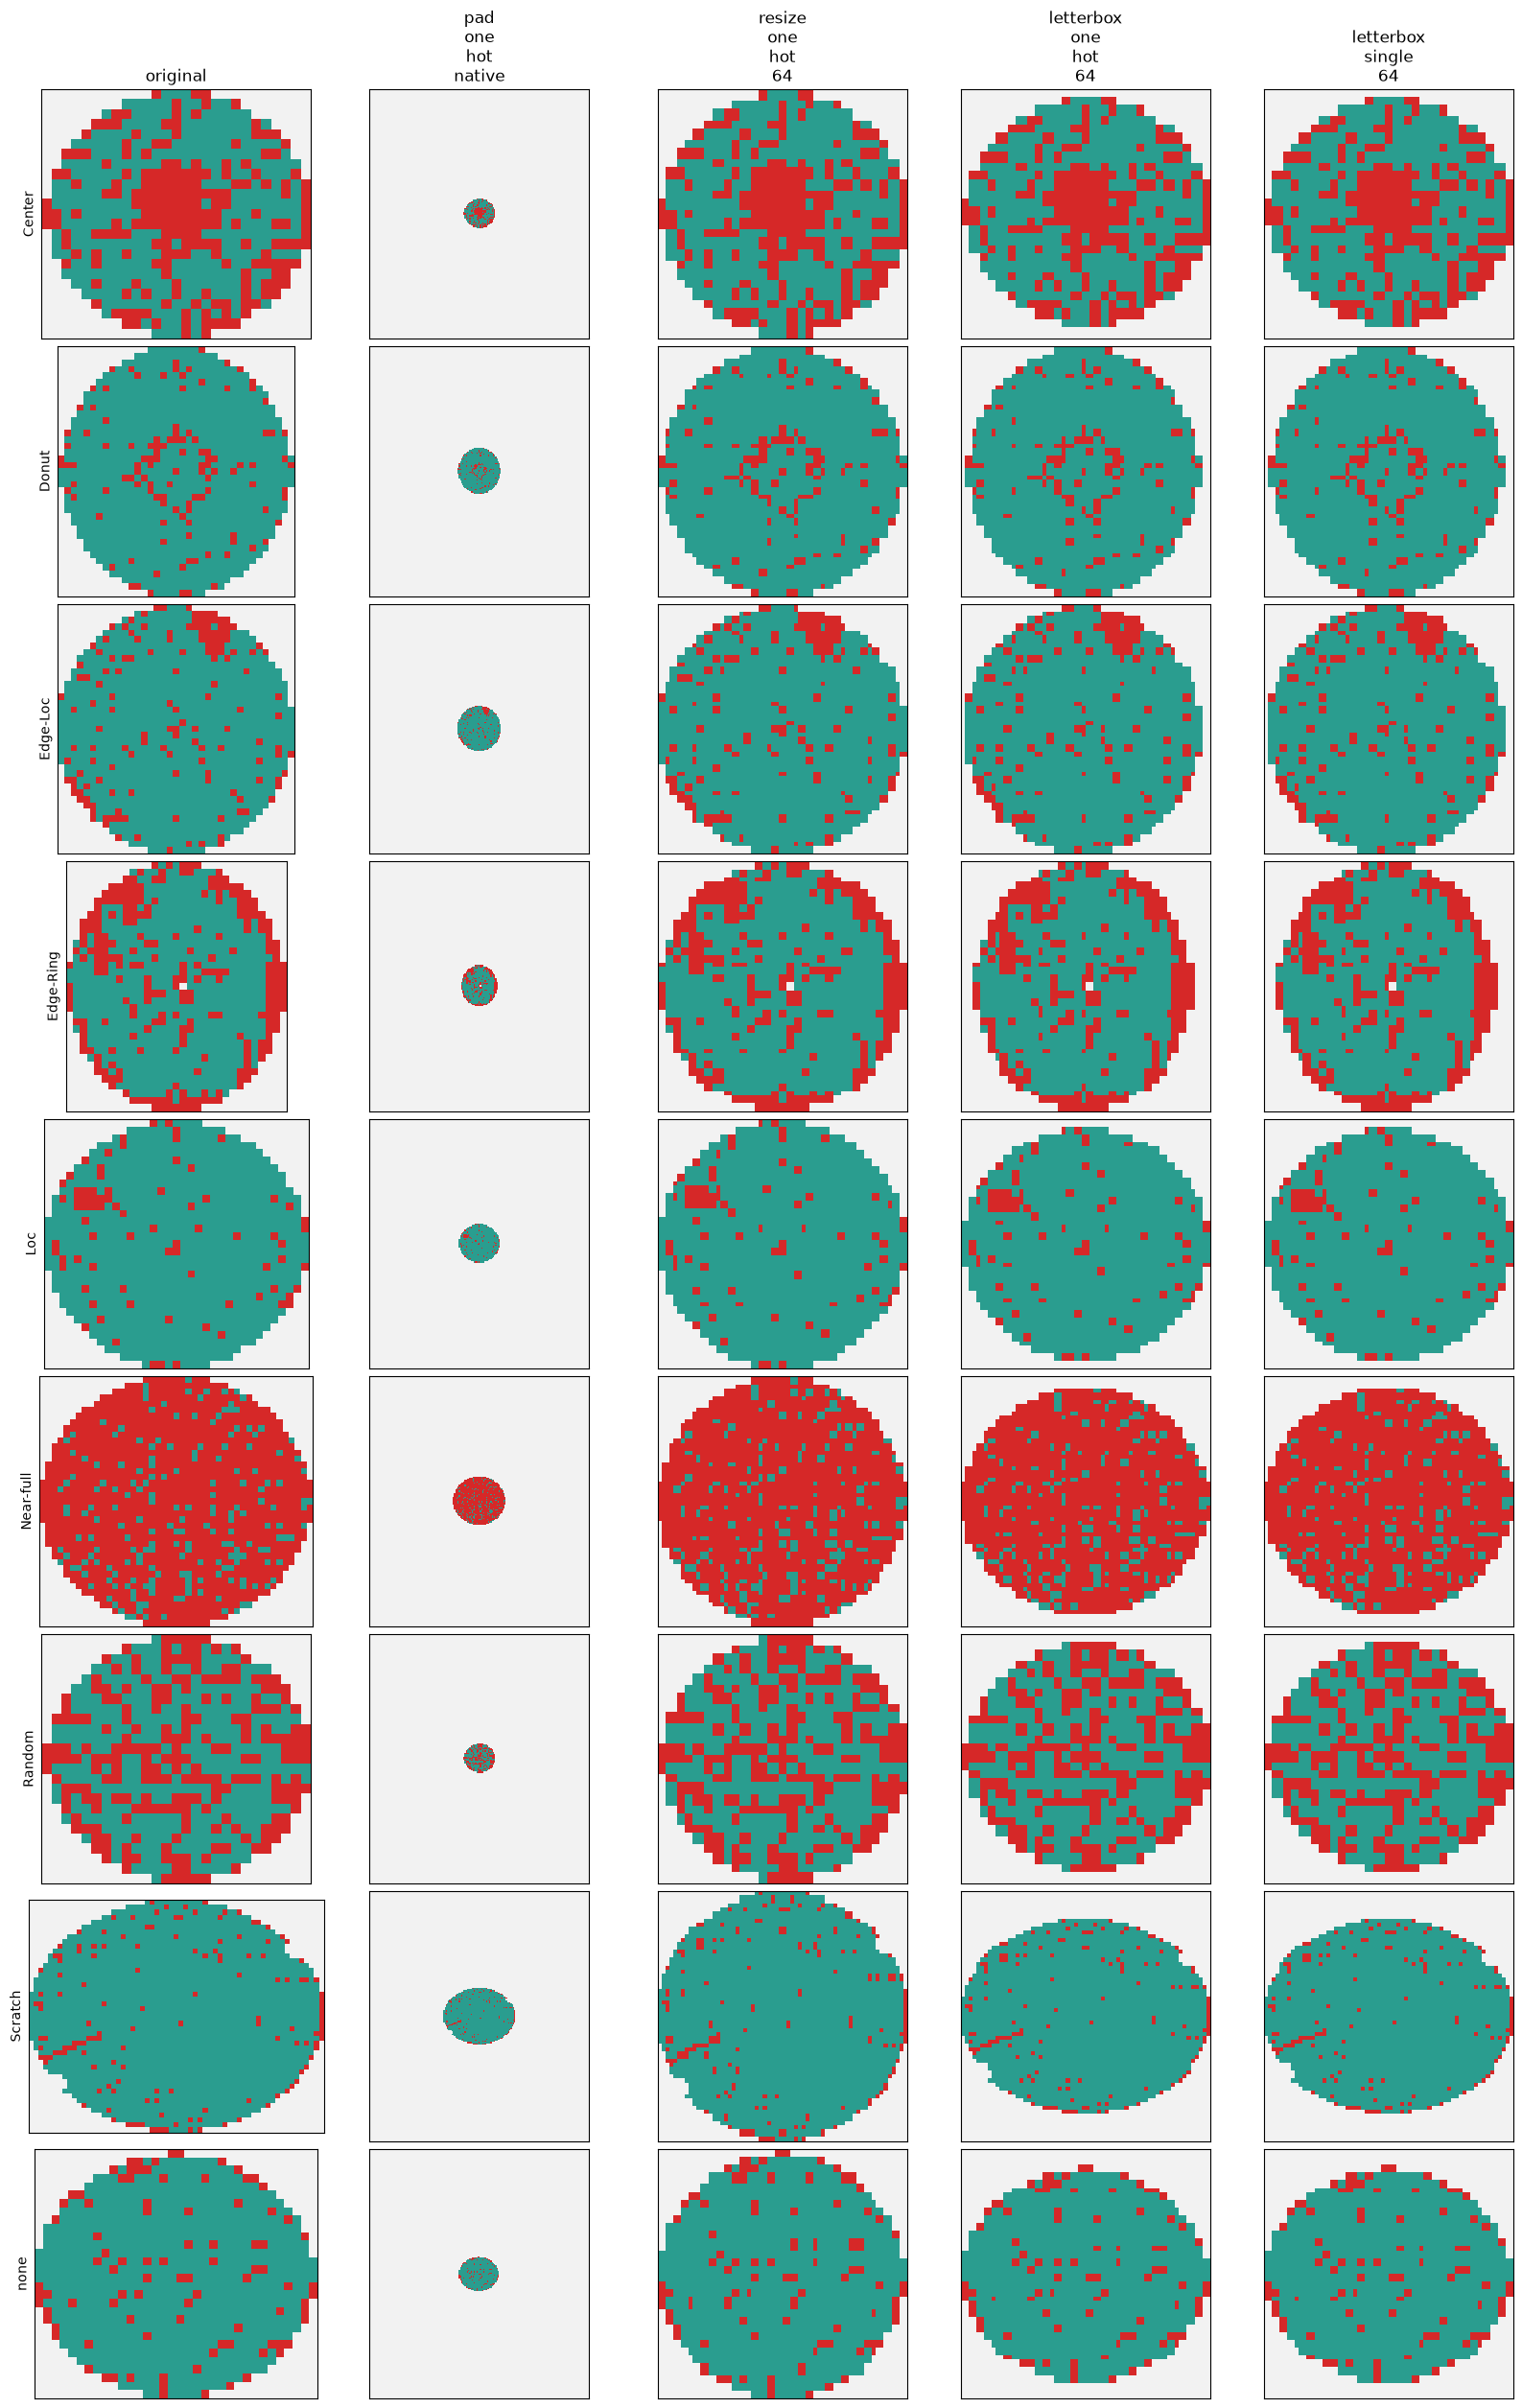

In [6]:
wafer_cmap = ListedColormap(["#F2F2F2", "#2A9D8F", "#D62828"])
wafer_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], wafer_cmap.N)
column_names = ["original", *preprocessors]
figure, axes = plt.subplots(
    len(CLASS_NAMES), len(column_names), figsize=(16, 25), constrained_layout=True
)

for row, class_name in enumerate(CLASS_NAMES):
    selected = sample_manifest.loc[sample_manifest["failureType"] == class_name].iloc[0]
    original = dataframe.at[int(selected["row_index"]), "waferMap"]
    panels = [original]
    for preprocessor in preprocessors.values():
        output = preprocessor(original)
        panels.append(decode_preprocessed_map(output, preprocessor.config).numpy())

    for column, (column_name, panel) in enumerate(zip(column_names, panels)):
        axes[row, column].imshow(
            panel, cmap=wafer_cmap, norm=wafer_norm, interpolation="nearest"
        )
        if row == 0:
            axes[row, column].set_title(column_name.replace("_", "\n"))
        if column == 0:
            axes[row, column].set_ylabel(class_name)
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])

figure.savefig(OUTPUT_DIRECTORY / "preprocessing_examples.png", dpi=160)
plt.show()

## Select and verify the default

The default is 64×64 aspect-ratio-preserving letterbox with three categorical channels. It avoids direct-resize deformation, uses far less spatial memory than the native canvas, and does not impose an artificial ordinal distance between wafer states. The test split remains untouched.

In [7]:
selected_name = "letterbox_one_hot_64"
selected_config = candidate_configs[selected_name]
assert selected_config == DEFAULT_PREPROCESSING_CONFIG

comparison_metadata = {
    "random_seed": RANDOM_SEED,
    "selection_split": "train",
    "test_set_used": False,
    "samples_per_class": SAMPLES_PER_CLASS,
    "sample_count": len(sample_manifest),
    "reference_batch_size": REFERENCE_BATCH_SIZE,
    "selected_candidate": selected_name,
    "selected_config": selected_config.to_dict(),
    "candidate_configs": {
        name: config.to_dict() for name, config in candidate_configs.items()
    },
}
with (OUTPUT_DIRECTORY / "comparison_metadata.json").open(
    "w", encoding="utf-8"
) as handle:
    json.dump(comparison_metadata, handle, indent=2)
    handle.write("\n")

validation_dataset = create_split_dataset(
    dataframe,
    SPLIT_DIRECTORY,
    "validation",
    preprocessing_config=selected_config,
)
validation_loader = create_dataloader(
    validation_dataset, batch_size=256, shuffle=False, num_workers=0
)
seen_row_indices = []
validation_batch_count = 0
for images, targets, row_indices in validation_loader:
    assert images.shape == (len(targets), 3, 64, 64)
    assert images.dtype == torch.float32
    assert targets.dtype == torch.long
    assert row_indices.dtype == torch.long
    assert torch.all(images.sum(dim=1) == 1)
    assert torch.all((targets >= 0) & (targets < len(CLASS_NAMES)))
    seen_row_indices.append(row_indices.numpy())
    validation_batch_count += 1

seen_row_indices = np.concatenate(seen_row_indices)
assert np.array_equal(seen_row_indices, validation_dataset.row_indices)
assert len(np.unique(seen_row_indices)) == len(validation_dataset)

print(f"Selected: {selected_name}")
print(f"Validation rows: {len(validation_dataset):,}")
print(f"Validated batches: {validation_batch_count:,}")
print(f"Final validation batch shape: {tuple(images.shape)}")
print("Frozen test set used for selection: no")

Selected: letterbox_one_hot_64
Validation rows: 34,591
Validated batches: 136
Final validation batch shape: (31, 3, 64, 64)
Frozen test set used for selection: no


## Conclusion

Use `DEFAULT_PREPROCESSING_CONFIG`: nearest-exact letterbox to 64×64 followed by a three-channel categorical one-hot representation. Pure native padding is the lossless reference but carries a much larger convolutional input. Direct resize is compact but changes wafer aspect ratios. The one-channel alternative is compact but introduces an ordinal numeric representation. Augmentation and class-imbalance interventions remain separate train-only experiments in tasks 09 and 05.